In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


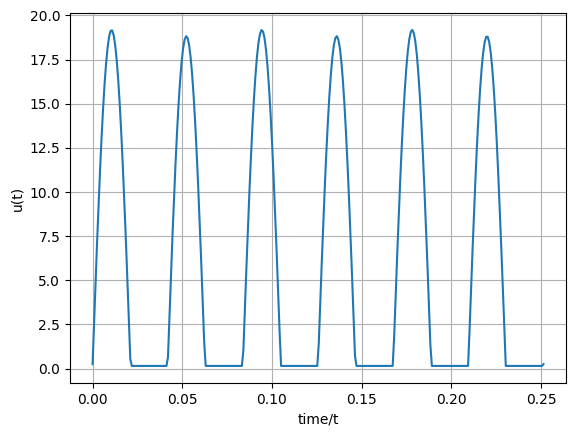

In [14]:
def u(t):
    omega1 = np.sin(75*t)
    omega2 = 75 * np.cos(75*t)

    func = 0.5 * ( omega1 * omega2 + omega1 ** 3 + 0.5)

    return np.where( func < 0.15, 0.15, func)

T = np.linspace(0, (6*np.pi) / 75, 300)
U = u(T)

plt.plot(T, U)
plt.grid(True)
plt.ylabel("u(t)")
plt.xlabel("time/t")
plt.show()





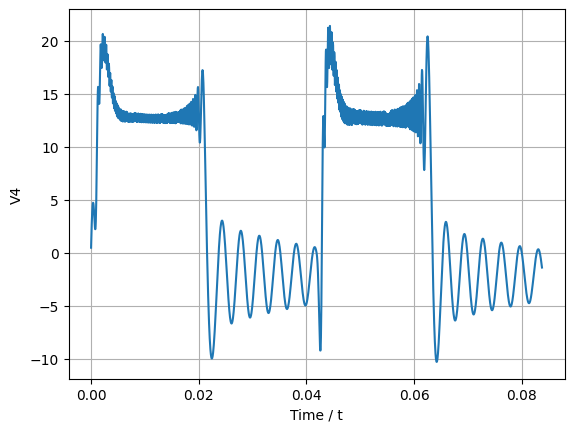

In [24]:
L1 = 10.0e-3
C2 = 22.0e-6
L3 = 10.0e-3
C4 = 22.9e-6
G = 0.0447
E = 12.0

def Cukconverter(t, x):
    x1, x2, x3, x4 = x
    u_val = u(t)

    dx1 = ( -(1.0 - u_val)*x2 + E) / L1
    dx2 = ( (1.0 - u_val ) * x1 + u_val*x3) / C2
    dx3 = (-u_val * x2 - x4) / L3
    dx4 = ( x3 - G*x4) / C4

    return [dx1, dx2, dx3, dx4]

x0 = [0.5 for _ in range(4)]
t_span = (0, (2 * np.pi) / 75)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Solve
sol = solve_ivp(Cukconverter, t_span, x0, t_eval=t_eval)

T_list = sol.t
v4_list = sol.y[3]  # x4

plt.plot(T_list, v4_list)
plt.grid(True)
plt.xlabel("Time / t")
plt.ylabel("V4")
plt.show()


